<a href="https://colab.research.google.com/github/juanfeolguin123-cmyk/portafolio-de-inversion/blob/main/portafolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
#instalacion del paquete yfinance
!pip install yfinance


In [26]:

import yfinance as yf


In [27]:
print(data.head())



Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-03-20  367.959991  379.890015  364.459991  379.850006  78628600
2026-03-23  380.850006  385.329987  372.730011  373.089996  74606000
2026-03-24  383.029999  387.480011  376.309998  376.559998  60004900
2026-03-25  385.950012  396.230011  385.010010  389.989990  55157300
2026-03-26  372.109985  384.440002  371.869995  381.600006  55522900


In [33]:
#bajamos la data de los cierres de tesla desde dos fechas distintas
data = yf.download("TSLA", start="2026-03-20", end="2026-04-25")





/tmp/ipykernel_8971/2016336296.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("TSLA", start="2026-03-20", end="2026-04-25")
[*********************100%***********************]  1 of 1 completed


In [34]:
#solo imprimimos la data de los cierres ya que es la que necesitamos para el simulador
precios = data["Close"]["TSLA"].tolist()

print(data["Close"])




Ticker            TSLA
Date                  
2026-03-20  367.959991
2026-03-23  380.850006
2026-03-24  383.029999
2026-03-25  385.950012
2026-03-26  372.109985
2026-03-27  361.829987
2026-03-30  355.279999
2026-03-31  371.750000
2026-04-01  381.260010
2026-04-02  360.589996
2026-04-06  352.820007
2026-04-07  346.649994
2026-04-08  343.250000
2026-04-09  345.619995
2026-04-10  348.950012
2026-04-13  352.420013
2026-04-14  364.200012
2026-04-15  391.950012
2026-04-16  388.899994
2026-04-17  400.619995
2026-04-20  392.500000
2026-04-21  386.420013
2026-04-22  387.510010
2026-04-23  373.720001
2026-04-24  376.299988


No tienes suficiente dinero
Precio: 367.9599914550781
Valor portafolio: 996.3204000854491
Precio: 380.8500061035156
Valor portafolio: 1005.4019146728515
Dividendo recibido: 20
No tienes suficiente dinero
Precio: 383.0299987792969
Valor portafolio: 1014.440700073242
No tienes suficiente dinero
Precio: 385.95001220703125
Valor portafolio: 1035.6019268798827
No tienes suficiente dinero
Precio: 372.1099853515625
Valor portafolio: 1007.9218731689452
No tienes suficiente dinero
Precio: 361.8299865722656
Valor portafolio: 987.3618756103515
No tienes suficiente dinero
Precio: 355.2799987792969
Valor portafolio: 974.261900024414
No tienes suficiente dinero
Precio: 371.75
Valor portafolio: 1007.2019024658202
No tienes suficiente dinero
Precio: 381.260009765625
Valor portafolio: 1026.2219219970702
No tienes suficiente dinero
Precio: 360.5899963378906
Valor portafolio: 984.8818951416015
No tienes suficiente dinero
Precio: 352.82000732421875
Valor portafolio: 969.3419171142577
No tienes suficiente 

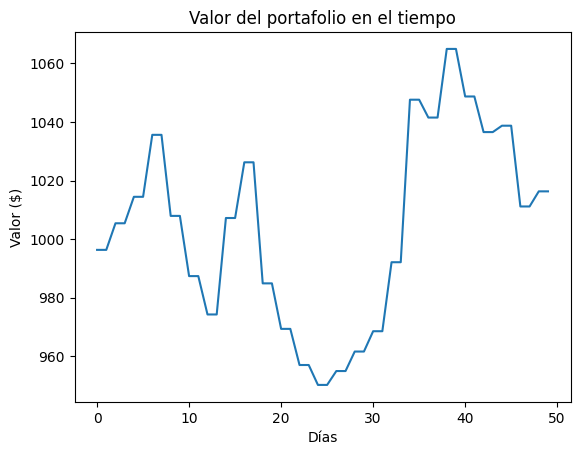

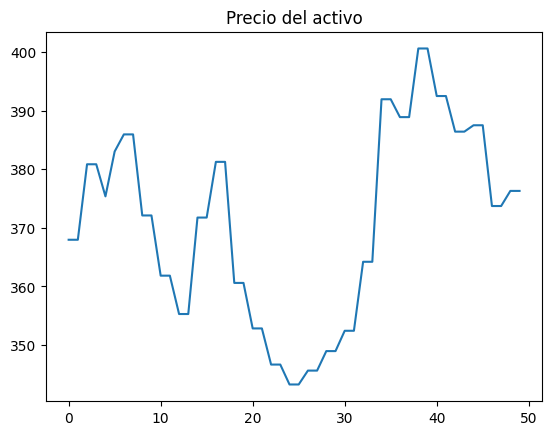

Rentabilidad: 1.63%


In [40]:
import matplotlib.pyplot as plt

#creacion clase activo para iniciar
class Activo:
    def __init__(self, nombre, precio):
        self.nombre = nombre
        self.precio = precio

class Portafolio:
    def __init__(self, capital_inicial):
        self.efectivo = capital_inicial
        self.activos = {}


# anexamos costos de comision del broker
    def comprar(self, activo, cantidad):
      comision = 0.01  # 1%

      costo = activo.precio * cantidad
      costo_total = costo * (1 + comision)

      if costo_total > self.efectivo:
        print("No tienes suficiente dinero")
        return

      self.efectivo -= costo_total

      if activo.nombre in self.activos:
        self.activos[activo.nombre]["cantidad"] += cantidad
      else:
        self.activos[activo.nombre] = {
            "activo": activo,
            "cantidad": cantidad
        }



    def valor_total(self):
      total = self.efectivo

      for item in self.activos.values():
          activo = item["activo"]
          cantidad = item["cantidad"]
          total += activo.precio * cantidad

      return total

# validacion de que el activo esta creado correctamente
tesla = Activo("Tesla", 1000)

bono = Activo("Bono", 100)
cdt = Activo("CDT", 100)


port = Portafolio(1000)

port.comprar(tesla, 1)

precios = data["Close"]["TSLA"].tolist()


tesla = Activo("Tesla", 1000)

# creamos estas listas para guardar los precios de los cierres de cada dia
historial_valor = []
historial_precios = []

for i, precio in enumerate(precios):
    tesla.precio = precio

    # Dividendo en un dia al azar
    if i == 2:
        dividendo = 10

        if "Tesla" in port.activos:
            cantidad = port.activos["Tesla"]["cantidad"]
            pago = cantidad * dividendo

            port.efectivo += pago
            tesla.precio *= 0.98

            print("Dividendo recibido:", pago)

    # analisis para ejecutar la operacion
    if precio < 390:
        port.comprar(tesla, 1)

    valor = port.valor_total()

    historial_valor.append(valor)
    historial_precios.append(tesla.precio)

# anexamos la variable de valor para que el ciclo vaya guardando los precios al
# cierre de cada dia con el find e elaborar la grafica
    valor = port.valor_total()

    historial_valor.append(valor)
    historial_precios.append(precio)

    print("Precio:", precio)
    print("Valor portafolio:", valor)

    #print(historial_valor)
# grafica del valor del portafolio con el tiempo
plt.plot(historial_valor)
plt.title("Valor del portafolio en el tiempo")
plt.xlabel("Días")
plt.ylabel("Valor ($)")
plt.show()
#grafica del precio a lo largo de los dias
plt.plot(historial_precios)
plt.title("Precio del activo")
plt.show()


capital_inicial = 1000
valor_final = port.valor_total()

rentabilidad = (valor_final - capital_inicial) / capital_inicial * 100

print(f"Rentabilidad: {rentabilidad:.2f}%")






